# PCA on 2D synthetic data

This notebook builds a simple artificial 2D example to show how PCA works on correlated points.

In [1]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
print("Done")

Done


**Create data and plot**

First we generate a random 2D point cloud and visualize its shape before applying PCA.

Text(0.5, 1.0, '300 Points of a given distribution')

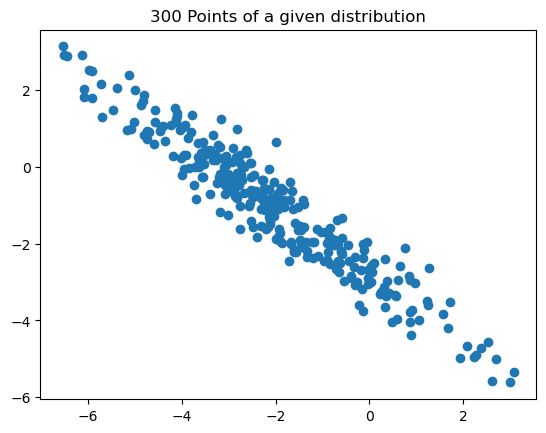

In [2]:
# create the random data
rnd = np.random.RandomState(5)
X_ = rnd.normal(size=(300, 2)) # 300 Samples, 2 coordinate value

#plt.scatter(X_[:,0], X_[:,1])

X_blob = np.dot(X_, rnd.normal(size=(2, 2))) + rnd.normal(size=2) # apply transformation matrix, rotate and skew
plt.scatter(X_blob[:,0], X_blob[:,1])
plt.title("300 Points of a given distribution")

**Plot data in original space and transformed space**

Here the same data is shown before and after PCA so you can compare the original axes with the principal components.

In [3]:
X_2D = X_blob 

pca = PCA() # max dimensions/pricipal components
pca.fit(X_2D)
X_pca = pca.transform(X_2D)

print("Original Shape: ", X_2D.shape)
print("Tranformed Shape: ", X_pca.shape)
print("PC1", pca.components_[0]);
print("PC2", pca.components_[1]);

Original Shape:  (300, 2)
Tranformed Shape:  (300, 2)
PC1 [ 0.74827666 -0.6633868 ]
PC2 [0.6633868  0.74827666]


(-8.0, 8.0)

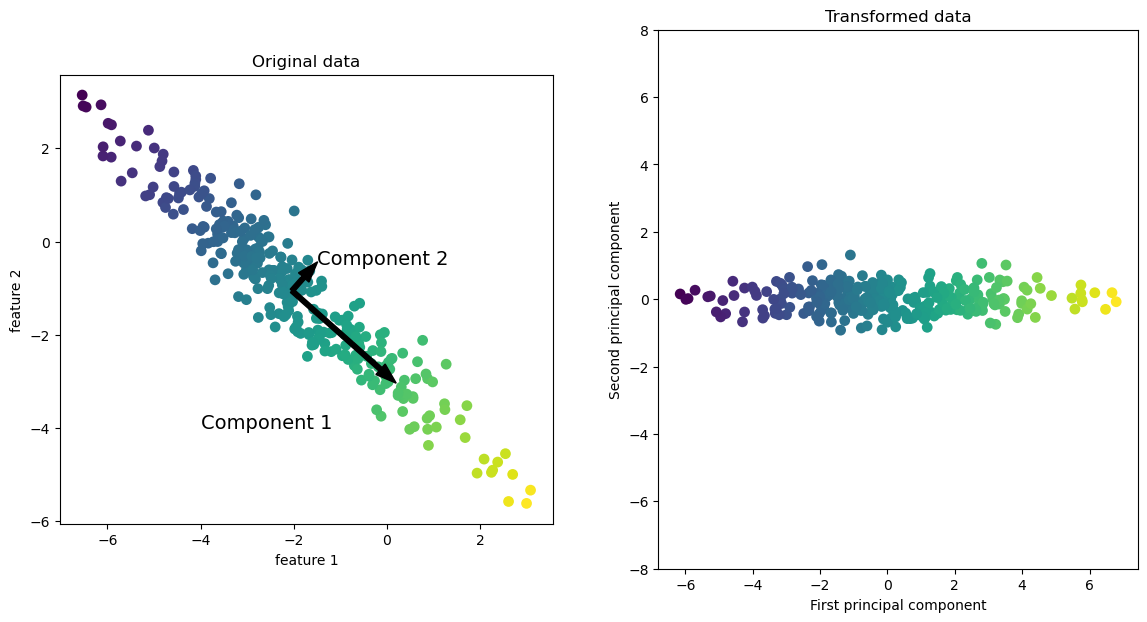

In [4]:
# Now plt point in both spaces
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
#---
axes[0].set_title("Original data")
axes[0].scatter(X_2D[:, 0], X_2D[:, 1], c=X_pca[:, 0], linewidths=0,
                    s=60, cmap='viridis')
axes[0].set_xlabel("feature 1")
axes[0].set_ylabel("feature 2")
S = X_pca.std(axis=0)

axes[0].arrow(pca.mean_[0], pca.mean_[1], S[0] * pca.components_[0, 0],
                  S[0] * pca.components_[0, 1], width=.1, head_width=.3,
                  color='k')
axes[0].arrow(pca.mean_[0], pca.mean_[1], S[1] * pca.components_[1, 0],
                  S[1] * pca.components_[1, 1], width=.1, head_width=.3,
                  color='k')
axes[0].text(-1.5, -.5, "Component 2", size=14)
axes[0].text(-4, -4, "Component 1", size=14)
axes[0].set_aspect('equal')
    
#---
axes[1].set_title("Transformed data")
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=X_pca[:, 0], linewidths=0,
                    s=60, cmap='viridis')
axes[1].set_xlabel("First principal component")
axes[1].set_ylabel("Second principal component")
axes[1].set_aspect('equal')
axes[1].set_ylim(-8, 8)

In [6]:
#dir(pca)
print(pca.explained_variance_ratio_)

[0.97798439 0.02201561]


<BarContainer object of 2 artists>

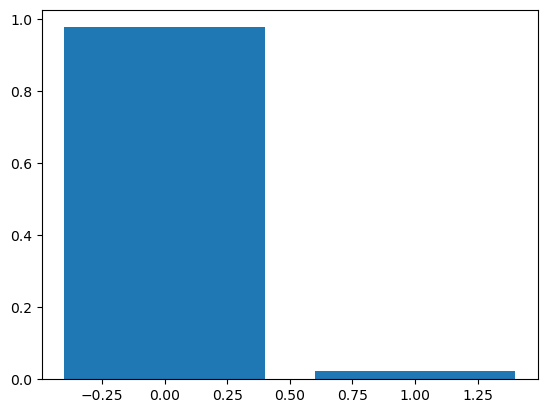

In [7]:
plt.bar(np.arange(len(pca.explained_variance_ratio_)), 
         pca.explained_variance_ratio_)

In [8]:
# Now use PCA with dimensionality reduction
X_2D = X_blob

pca = PCA(n_components=1)  # limitation to one dimension / projection to the most important PC
pca.fit(X_2D)
transformed = pca.transform(X_2D)
print("Dimension of the initial data:", X_2D.shape)
print("Dimension of the transformed data:", transformed.shape)


Dimension of the initial data: (300, 2)
Dimension of the transformed data: (300, 1)


(-8.0, 4.0)

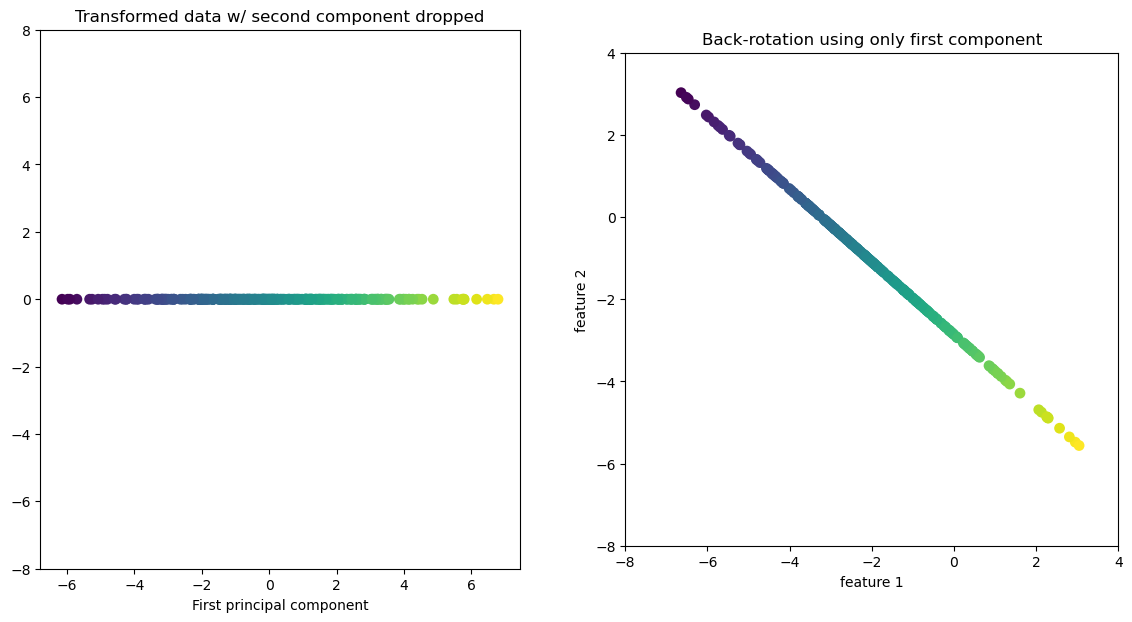

In [9]:

# Plot the graph of the transformed data with reducted dimensions
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].set_title("Transformed data w/ second component dropped")
axes[0].scatter(transformed[:, 0], np.zeros(transformed.shape[0]), c=X_pca[:, 0],
                    linewidths=0, s=60, cmap='viridis')
axes[0].set_xlabel("First principal component")
axes[0].set_aspect('equal')
axes[0].set_ylim(-8, 8)

# Take the new data and rotate it back
X_inverse = pca.inverse_transform(transformed)

axes[1].set_title("Back-rotation using only first component")
axes[1].scatter(X_inverse[:, 0], X_inverse[:, 1], c=X_pca[:, 0],
                    linewidths=0, s=60, cmap='viridis')
axes[1].set_xlabel("feature 1")
axes[1].set_ylabel("feature 2")
axes[1].set_aspect('equal')
axes[1].set_xlim(-8, 4)
axes[1].set_ylim(-8, 4)

**Optional content: Manually calculate and plot Eigenvectors without Scikit learn**

This extra section shows the PCA steps manually with NumPy so the lecture theory and the library result can be compared directly.

Covariance Matrix [[ 1.         -0.95536957]
 [-0.95536957  1.        ]]
Eigenvalues [0.04463043 1.95536957]
Eigenvectors [[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]


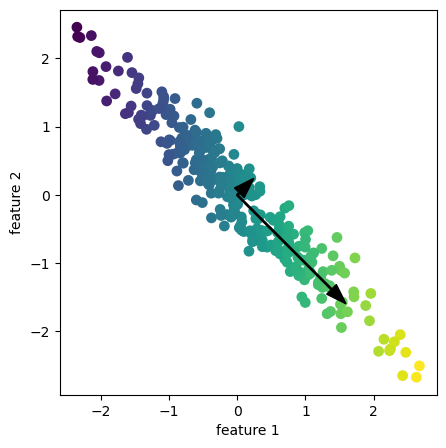

In [10]:
# Create Data
rnd = np.random.RandomState(5)
X = rnd.normal(size=(300, 2))#distribute
X = np.dot(X, rnd.normal(size=(2, 2))) #rotate

# Normalize and Scale Data
X= X-np.mean(X, axis=0) #zero mean
X= X/np.std(X, axis=0) #rescale

# Calculate Covariance Matrix and Eigenstuff 
C = (1/(X.shape[0])) * X.T.dot(X)
print("Covariance Matrix", C)
eval,evec = np.linalg.eigh(C);
print("Eigenvalues", eval)
print("Eigenvectors", evec)

# Plot Data and Vectors
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
axes.scatter(X[:, 0], X[:, 1], linewidths=0,
                    s=60, cmap='viridis', c=X[:, 0])
axes.arrow(0, 0, (-eval[0])*evec[0][0],
                  (-eval[0])*evec[0][1], width=.02, head_width=.2,
                  color='k')
axes.arrow(0, 0, (-eval[1])*evec[1][0],
                  (-eval[1])*evec[1][1], width=.02, head_width=.2,
                  color='k')
axes.set_xlabel("feature 1")
axes.set_ylabel("feature 2")
axes.set_aspect('equal')